In [98]:
from langgraph.graph import StateGraph, START, END
import os
from typing import List, TypedDict, Literal, Annotated
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
import operator

In [99]:
generator_llm  = init_chat_model("google_genai:gemini-2.5-flash-lite")
evaluator_llm  = init_chat_model("google_genai:gemini-2.5-flash-lite")
optimizer_llm  = init_chat_model("google_genai:gemini-3-flash-preview")
optimizer_llm.invoke("hi")

AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'Ev8BCvwBAQw51sdEuIqTeRh+LBXTK1TCRlhiarKQctRdpPdy9QMCfUVr1s8oRNcypkTCA5X+t2dNBEG0GuD5kfned/S1hLLLSjdJOwoY3FAiT3qjavPsml++agl+S/yz/KwLc8l/IzflRdZyuyQ0hOFTt3Wq/vSRRmDFW1wG5hH3FpOpwXOr2NPm0uRJC8wrh8PQgc/zmv1bE4Zl4WX3Z6z25bSU2dXTBJ3xUE88xoPMg2GnLcOBl3Ck56DrZY/KoLzn2XUhAVDsADZ9yaZARia8vmWmKzGvC9Ql0DbqP5VFpF0i4qo+9URL+zKNPOK6bTSS4hmJHvqO3poLAFa2qGnK'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc49d-5bfd-7850-adfc-7c41c1d90780-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 62, 'total_tokens': 64, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 53}})

In [100]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [101]:

structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [102]:
##create state graph

class tweetpost_state(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [103]:
def generate_post_node(state: tweetpost_state):
    messages = [
        SystemMessage(content="You are a helpful assistant that generates a tweet based on the given topic."),
        HumanMessage(content=f"""Generate a tweet about the following topic: "{state['topic']}" .
                     Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    **Rules:**
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english, and avoid complex words.
    - This is version of iteration {state['iteration']}
    """)
    ]
    
    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [104]:
def evaluate_post_node(state: tweetpost_state):
    # prompt
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [105]:
def optimizer_post_node(state: tweetpost_state):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [106]:
def route_evaluation(state: tweetpost_state):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

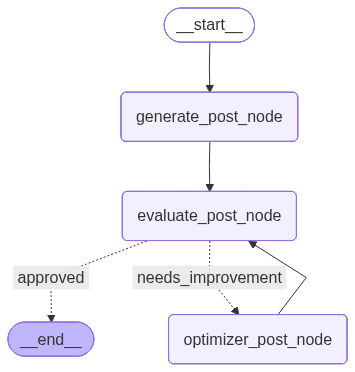

In [107]:
graph = StateGraph(tweetpost_state)

### nodes

graph.add_node("generate_post_node",generate_post_node)
graph.add_node("evaluate_post_node",evaluate_post_node)
graph.add_node("optimizer_post_node",optimizer_post_node)

### Edges
graph.add_edge(START, "generate_post_node")
graph.add_edge("generate_post_node", "evaluate_post_node")
graph.add_conditional_edges("evaluate_post_node", route_evaluation, {'approved': END,'needs_improvement': "optimizer_post_node"})
graph.add_edge("optimizer_post_node", "evaluate_post_node")

workflow = graph.compile()

workflow

In [ ]:
initial_state = {
    "topic": "Agentic agents",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [109]:
result

{'topic': 'srhberhb',
 'tweet': [{'type': 'text',
   'text': 'Tried to pronounce "srhberhb" out loud and accidentally summoned a Victorian child who is currently sobbing because he’s never seen a microwave. This is on me.',
   'extras': {'signature': 'Eps3Cpg3AQw51sdoi0YMeM3NBHBqkJwMvADuXwB7OsnStY3+xE8UI2SwF8C83/cePM2N874LX/OkI1cz9YEixc3aEGzrNZdF6kNhwdfGcQwT4GJ8f3f5HHlc33FNWObAlxJ07LO7WZlEdi+qxJpS2D1gnGEI2OompqmfkIaoDO+IlWkWKyTEyi70CGfFJksf1wwgPHDUX8mor2rLMdhOTkgLBsl9A6hJ+5diE9okgHxXET+TPCFw3i6RN0LVK9IwAJugCiT+FBE63O4qRKfgb6M7XXdDI6ikZXnC80Kb66kXViXB0DX0kxU+eIZjMkOpcCoQ8IXshjd8qz4LEGr9F/DrK8+Cao50TI2zyOIkB/jd5ZM/3lU3xaQ7mI5CUw6U2eIzu7BF21W5ST/AYyB1Wn8TRDsosIyIIHkuTfXBLTGu1camwp20yyCwZ3e+x5t/FaNFSZbp7EYxRitVJoGkN9YSNRVEyu3hjzQ4skuZDjut8/YEnyV88Pd9z0uaKuMbfKxSDzGRFQfP79GP9g3l9zg+k3CkTZW7MhlDJLCf0cMOl+4+hX1p7RzTiw9Iv8vtjqmyA9sYpWR0aZ950aMfnuQu7t5W0Ua+PGx/ZwHeX5RTO4ffPgSb5tI1ZS0Zpd3gelEfn+qZxD2B0+70/KYve9ouoy+iiPmCGiQ8fo6YRDJlzEL1SyH0WhXu1uUEE9WuONiZBIBxDlGu1MHXI/txBInsqPAjNf9zyq61YIJt6DaW

In [110]:
## handle result
# print("Final Tweet:", result['tweet'])
# print("Evaluation:", result['evaluation'])  
# print("Feedback History:", result['feedback_history'])
# for tweet in result['tweet_history']:
#     print(tweet)